In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [2]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data Mining/data_ecommerce_customer_churn.csv'
data = pd.read_csv(file_path)
data

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


Menangani missing values

In [4]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_1402/3087983242.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_1402/3087983242.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Mengubah fitur kategorikal menjadi numerik

In [6]:
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    if col != 'Churn': # Pastikan kita tidak mengubah kolom target terlebih dahulu
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le # Simpan encoder jika nanti perlu di-inverse

Memisahkan fitur (X) dan target (Y)

In [8]:
X = data.drop('Churn', axis=1)
y = data['Churn']

Membagi data menjadi data latih dan data uji

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Melakukan standarisasi (Feature scaling)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Mencari nilai k optimal

In [13]:
param_grid = {'n_neighbors': np.arange(1, 31)} # Uji K dari 1 hingga 30
knn_grid = KNeighborsClassifier()
grid_search = GridSearchCV(knn_grid, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print(f"Nilai K terbaik: {grid_search.best_params_['n_neighbors']}")

Nilai K terbaik: 1


Melatih Model KNN dengan K Terbaik

In [14]:
best_k = grid_search.best_params_['n_neighbors']
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=np.int64(1))

Melakukan Prediksi pada Data Uji

In [15]:
y_pred = knn_model.predict(X_test_scaled)
y_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

Evaluasi model dengan mengukur akurasi pada data

In [19]:
print(f"{accuracy_score(y_test, y_pred):.4f}")

0.9202


Laporan klasifikasi

In [24]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.94      0.97      0.95       654\n           1       0.81      0.70      0.75       135\n\n    accuracy                           0.92       789\n   macro avg       0.87      0.83      0.85       789\nweighted avg       0.92      0.92      0.92       789\n'

Membuat visualisasi confusion matrix

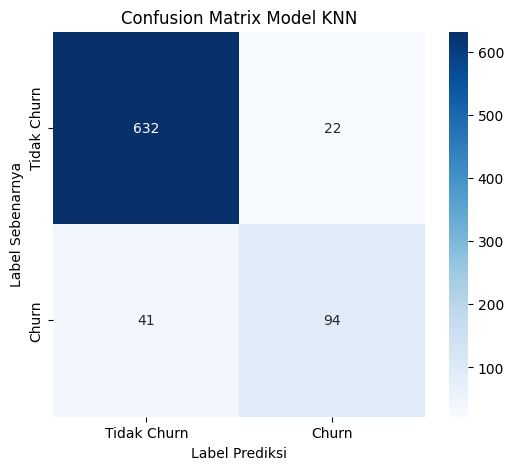

In [20]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Churn', 'Churn'], yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix Model KNN')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Sebenarnya')
plt.show()